# Feature Selection, Train / Validation / Test Modelling Notebook
## South African Residential Property Investment ML Project

### Objective

In this notebook, I move from the engineered dataset into model development.

The aim is not to maximise notebook accuracy at any cost.
The aim is to build a model that can realistically support financed property investment decisions.

That means I must:

- use only features that are available at decision time
- avoid financial-output leakage
- preserve the investment logic of the project
- evaluate performance in a way that reflects business usefulness

### Business framing

This project is designed for a first-time or emerging residential property investor in South Africa.

The model should help answer:

> Based on the listing, local rent evidence, operating cost assumptions, and financing structure, is this property likely to be a weak, moderate, or strong investment?

So the model must learn from:
- property characteristics
- local market context
- rental strength
- operating burden
- leverage structure
- rent estimate confidence

It must not cheat by using downstream outputs such as:
- ROI
- DSCR
- cash flow
- rental yield
- NOI

Those outputs belong to the financial engine, not the ex-ante prediction problem.

# 1. Imports and setup

In [2]:
# =========================================================
# 1. Imports and setup
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 2. Load data

In [5]:
# =========================================================
# 2. Load data
# =========================================================

DATA_PATH = Path("data/processed/financial_engine_feature_engineered_model_ready.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (9009, 171)


,purchase_price,suburb,city,province,property_type,bedrooms,bathrooms,parking_spaces,garage,floor_area_sqm,land_area_sqm,levies,rates_taxes,purchase_price_rands,rent_median_suburb_type_bed,rent_mean_suburb_type_bed,rent_count_suburb_type_bed,rent_median_suburb_bed,rent_mean_suburb_bed,rent_count_suburb_bed,rent_median_suburb,rent_mean_suburb,rent_count_suburb,rent_median_city_type_bed,rent_mean_city_type_bed,rent_count_city_type_bed,rent_median_city,rent_mean_city,rent_count_city,rent_median_province,rent_mean_province,rent_count_province,estimated_monthly_rent,rent_estimation_source,deposit_pct,deposit_amount,transfer_cost_rate,transfer_costs,total_cash_invested,loan_amount,annual_interest_rate,loan_term_years,bond_payment,other_income,gross_income,levies_clean,rates_taxes_clean,maintenance_rate,vacancy_rate,maintenance_cost,vacancy_cost,total_expenses,annual_rent,total_rooms_proxy,floor_to_land_ratio,bedroom_density_floor,bathroom_density_floor,parking_total,parking_per_bedroom,is_compact_unit,is_family_sized_unit,is_large_land_property,price_per_sqm,price_per_land_sqm,price_per_bedroom,price_per_bathroom,price_vs_suburb_median_rent_multiple,price_vs_city_median_rent_multiple,suburb_type_median_price_per_sqm,price_per_sqm_vs_local_median,rent_per_sqm,rent_per_bedroom,rent_per_bathroom,gross_rent_to_price,monthly_rent_to_price,rent_vs_suburb_median,rent_vs_city_median,rent_vs_province_median,rent_vs_suburb_type_bed_median,rent_vs_suburb_bed_median,annual_rent_per_sqm,levies_to_rent,rates_to_rent,bond_to_rent,maintenance_to_rent,vacancy_to_rent,opex_to_rent,opex_to_income,fixed_cost_burden,non_debt_opex,non_debt_opex_to_rent,ltv,deposit_to_price,cash_invested_to_price,transfer_costs_to_price,bond_payment_to_income,rent_source_score,rent_estimate_observation_count,rent_estimate_low_evidence_flag,rent_estimate_high_evidence_flag,rent_dispersion_suburb_type_bed,rent_dispersion_suburb,rent_dispersion_city,suburb_listing_density,city_listing_density,property_type_density,suburb_price_median,city_price_median,price_vs_suburb_price_median,price_vs_city_price_median,suburb_rent_median_feature,city_rent_median_feature,rent_vs_suburb_internal_median,rent_vs_city_internal_median,floor_area_sqm_missing_flag,land_area_sqm_missing_flag,garage_missing_flag,parking_spaces_missing_flag,rent_median_suburb_type_bed_missing_flag,rent_median_suburb_bed_missing_flag,rent_median_suburb_missing_flag,rent_median_city_type_bed_missing_flag,price_per_sqm_win,price_per_land_sqm_win,rent_per_sqm_win,gross_rent_to_price_win,monthly_rent_to_price_win,levies_to_rent_win,rates_to_rent_win,bond_to_rent_win,opex_to_rent_win,cash_flow_margin_win,ltv_win,bond_payment_to_income_win,debt_service_headroom_win,price_per_sqm_vs_local_median_win,rent_vs_suburb_median_win,rent_vs_city_median_win,price_vs_suburb_price_median_win,price_vs_city_price_median_win,rent_mean_suburb_type_bed_missing_flag,rent_count_suburb_type_bed_missing_flag,rent_mean_suburb_bed_missing_flag,rent_count_suburb_bed_missing_flag,rent_mean_suburb_missing_flag,rent_count_suburb_missing_flag,rent_mean_city_type_bed_missing_flag,rent_count_city_type_bed_missing_flag,floor_to_land_ratio_missing_flag,bedroom_density_floor_missing_flag,bathroom_density_floor_missing_flag,parking_per_bedroom_missing_flag,price_per_sqm_missing_flag,price_per_land_sqm_missing_flag,price_per_bedroom_missing_flag,price_vs_suburb_median_rent_multiple_missing_flag,price_per_sqm_vs_local_median_missing_flag,rent_per_sqm_missing_flag,rent_per_bedroom_missing_flag,rent_vs_suburb_median_missing_flag,rent_vs_suburb_type_bed_median_missing_flag,rent_vs_suburb_bed_median_missing_flag,annual_rent_per_sqm_missing_flag,rent_dispersion_suburb_type_bed_missing_flag,rent_dispersion_suburb_missing_flag,price_per_sqm_win_missing_flag,price_per_land_sqm_win_missing_flag,rent_per_sqm_win_missing_flag,price_per_sqm_vs_local_median_win_missing_flag,rent_vs_suburb_median_win_missing_flag,investment_label
0,"890,000.0000",Broadacres,Sandton,Gaute

## Validate the dataset before modelling

Before I split the data, I confirm:

- target exists
- direct leakage columns are not still present
- data types make sense
- class balance is visible

# 3. Dataset validation

In [6]:
# =========================================================
# 3. Dataset validation
# =========================================================

target_col = "investment_label"

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

possible_leakage_cols = [
    "NOI",
    "cash_flow",
    "DSCR",
    "annual_cash_flow",
    "rental_yield",
    "ROI",
    "equity_12m",
    "payments_made_12m",
    "remaining_balance_12m",
    "noi_margin",
    "cash_flow_margin",
    "cash_flow_to_cash_invested",
    "equity_12m_to_cash_invested",
    "debt_service_headroom",
    "positive_cash_flow_flag",
    "dscr_above_one_flag",
    "dscr_above_1_2_flag",
    "bond_payment_to_noi"
]

still_present = [c for c in possible_leakage_cols if c in df.columns]
print("Leakage columns still present:", still_present)

Leakage columns still present: []


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9009 entries, 0 to 9008
Columns: 171 entries, purchase_price to investment_label
dtypes: float64(115), int64(50), object(6)
memory usage: 11.8+ MB


# 4. Target distribution

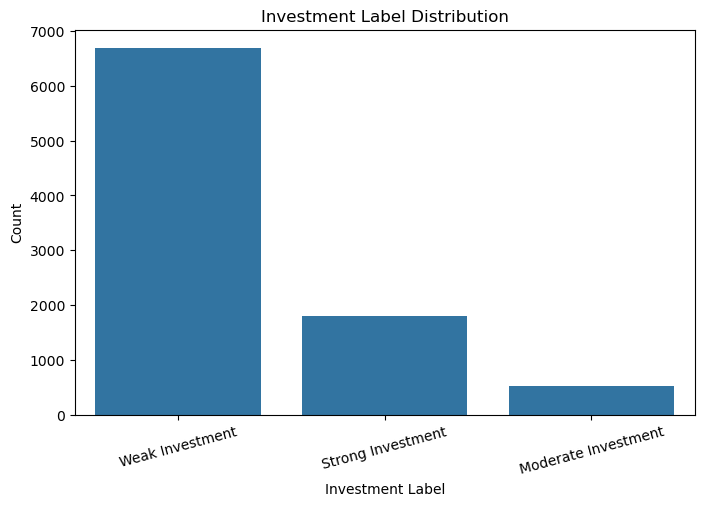

investment_label
Weak Investment       74.2500
Strong Investment     19.8900
Moderate Investment    5.8600
Name: proportion, dtype: float64

In [8]:
# =========================================================
# 4. Target distribution
# =========================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Investment Label Distribution")
plt.xlabel("Investment Label")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

df[target_col].value_counts(normalize=True).mul(100).round(2)

## Why this matters

I expect this dataset to contain many more weak investments than strong ones.

That is not a defect.
That is financially realistic.

Most properties listed in the market do not become excellent financed investments after:
- bond repayment
- vacancy allowance
- maintenance
- levies
- rates and taxes

So I do not force balance here.
Instead, I let the modelling process account for it.

# 5. Separate X and Y

In [9]:
# =========================================================
# 5. Separate X and y
# =========================================================

X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y_raw.shape)

X shape: (9009, 170)
y shape: (9009,)


# 6 Encode target

## Encode the target

The business labels are:
- Weak Investment
- Moderate Investment
- Strong Investment

I encode them for modelling, but I keep the class names for interpretation later.

In [10]:
# =========================================================
# 6. Encode target
# =========================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inverse_target_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

print("Target mapping:")
print(target_mapping)

Target mapping:
{'Moderate Investment': np.int64(0), 'Strong Investment': np.int64(1), 'Weak Investment': np.int64(2)}


# 7. Column type identification

In [11]:
# =========================================================
# 7. Column type identification
# =========================================================

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("\nSample categorical columns:", categorical_cols[:20])

Numeric columns: 165
Categorical columns: 5

Sample categorical columns: ['suburb', 'city', 'province', 'property_type', 'rent_estimation_source']


## Why I keep categorical columns

For this project, location and property structure are important.

That means columns such as:
- suburb
- city
- province
- property_type
- rent_estimation_source

can carry real predictive value.

I do not drop them.
I encode them properly inside the modelling pipeline.

# 8. Train / validation / test split

I use a three-way split because this project needs disciplined model selection:

- **train** for fitting
- **validation** for model comparison and tuning
- **test** for final untouched evaluation

I use stratification so that the class distribution remains stable across splits.

In [13]:
# =========================================================
# 8. Train / validation / test split
# =========================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1765,   # makes approx 70 / 15 / 15 overall
    random_state=42,
    stratify=y_train_full
)

print("Train shape      :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Test shape       :", X_test.shape)

Train shape      : (6305, 170)
Validation shape : (1352, 170)
Test shape       : (1352, 170)


In [14]:
def show_class_balance(y_array, name):
    values, counts = np.unique(y_array, return_counts=True)
    labels = [inverse_target_mapping[v] for v in values]
    out = pd.DataFrame({
        "label": labels,
        "count": counts,
        "pct": (counts / counts.sum()) * 100
    })
    print(f"\n{name}")
    print(out)

show_class_balance(y_train, "Train")
show_class_balance(y_val, "Validation")
show_class_balance(y_test, "Test")


Train
                 label  count     pct
0  Moderate Investment    370  5.8684
1    Strong Investment   1254 19.8890
2      Weak Investment   4681 74.2427

Validation
                 label  count     pct
0  Moderate Investment     79  5.8432
1    Strong Investment    269 19.8964
2      Weak Investment   1004 74.2604

Test
                 label  count     pct
0  Moderate Investment     79  5.8432
1    Strong Investment    269 19.8964
2      Weak Investment   1004 74.2604


# 9 Preprocessing strategy

I do not preprocess outside the pipeline.

That is important because:
- imputation should be fitted only on training data
- scaling should be fitted only on training data
- encoding should be learned only from training data

This avoids leakage from the validation and test sets.

### Numeric preprocessing
- median imputation
- scaling

### Categorical preprocessing
- most frequent imputation
- one-hot encoding

In [15]:
# =========================================================
# 9. Preprocessing pipeline
# =========================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# 10 Start with a baseline model

Before I do feature selection and model comparison, I start with a baseline.

I use multinomial logistic regression because:
- it is interpretable
- it is disciplined
- it gives me a strong baseline for structured classification

If more complex models do not materially improve on this, that is important information.

In [16]:
# =========================================================
# 10. Baseline model
# =========================================================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="auto",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

val_preds_baseline = baseline_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_preds_baseline))
print("Validation Macro F1:", f1_score(y_val, val_preds_baseline, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_val, val_preds_baseline, target_names=label_encoder.classes_))

Validation Accuracy: 0.9704142011834319
Validation Macro F1: 0.919683226826084

Classification Report:

                     precision    recall  f1-score   support

Moderate Investment       0.67      0.99      0.80        79
  Strong Investment       1.00      0.96      0.98       269
    Weak Investment       1.00      0.97      0.99      1004

           accuracy                           0.97      1352
          macro avg       0.89      0.97      0.92      1352
       weighted avg       0.98      0.97      0.97      1352



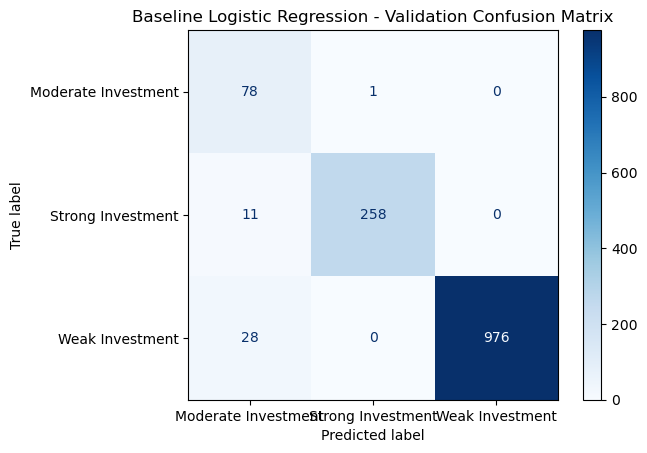

In [17]:
cm = confusion_matrix(y_val, val_preds_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Baseline Logistic Regression - Validation Confusion Matrix")
plt.show()

## Model Evaluation Interpretation & Analysis

### Overall Performance

- **Accuracy: 0.97** indicates very strong overall predictive performance  
- However, due to class imbalance (large number of Weak investments), accuracy alone is not sufficient  
- **Macro F1: 0.92** confirms the model performs well across all classes, providing a more balanced evaluation  

## Confusion Matrix Interpretation

### Weak Investment
- Correct predictions: **976 / 1004**
- Misclassified as Moderate: **28**
- Misclassified as Strong: **0**

**Interpretation:**
- Weak investments are identified with very high reliability  
- No instances where Weak deals are classified as Strong  
- Most errors fall into Moderate, indicating conservative misclassification  

### Strong Investment
- Correct predictions: **258 / 269**
- Misclassified as Moderate: **11**
- Misclassified as Weak: **0**

**Interpretation:**
- Strong investments are accurately identified  
- Some confusion with Moderate, but none are incorrectly classified as Weak  
- Indicates clear separation from Weak class  

### Moderate Investment
- Correct predictions: **78 / 79**
- Misclassified as Strong: **1**

**Interpretation:**
- Moderate class shows very high recall  
- Receives misclassifications from both Strong and Weak classes  
- Acts as an intermediate category where overlapping cases are assigned  

---

##  Classification Report Interpretation

### Precision
- Moderate: **0.67** - Lower due to overlap with other classes  
- Strong: **1.00** - Perfect precision  
- Weak: **1.00** - Perfect precision  

**Interpretation:**
- Predictions for Strong and Weak are highly reliable  
- Moderate predictions are less precise due to class ambiguity  

### Recall
- Moderate: **0.99**  
- Strong: **0.96**  
- Weak: **0.97**

**Interpretation:**
- The model successfully captures most true instances across all classes  
- Very few actual cases are missed  

### F1-Score
- Moderate: **0.80**  
- Strong: **0.98**  
- Weak: **0.99**

**Interpretation:**
- Strong and Weak classes have excellent balance between precision and recall  
- Moderate class has lower F1 due to reduced precision  

---

##  Macro vs Weighted Metrics

- **Macro F1: 0.92** - Balanced performance across classes  
- **Weighted F1: 0.97** - Influenced by dominant Weak class  

**Interpretation:**
- Performance is consistently strong across all classes  
- Slight reduction in Macro F1 reflects difficulty in the Moderate class  

---

##  Summary Interpretation

- The model demonstrates strong classification ability across all classes  
- Weak and Strong classes are clearly distinguished with minimal critical errors  
- Moderate class shows overlap with both neighbouring classes, reflected in lower precision  
- Overall performance is high, with balanced metrics confirming reliable multi-class behavior  

# 11. Feature selection

This project already has financially meaningful engineered variables.
So feature selection is not about blindly reducing columns.
It is about identifying which features carry the most predictive signal without drifting away from the business logic.

I use three complementary approaches:

1. **Mutual information**
   - captures non-linear dependency
2. **ANOVA F-score**
   - captures linear group separation
3. **Tree-based importance**
   - captures interaction-rich importance

I use them together because no single method is sufficient on its own.

In [18]:
# =========================================================
# 11. Fit preprocessor on training only
# =========================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [19]:
# =========================================================
# 12. Recover transformed feature names
# =========================================================

feature_names = preprocessor.get_feature_names_out()

print("Transformed feature count:", len(feature_names))
feature_names[:20]

Transformed feature count: 383


array(['num__purchase_price', 'num__bedrooms', 'num__bathrooms',
       'num__parking_spaces', 'num__garage', 'num__floor_area_sqm',
       'num__land_area_sqm', 'num__levies', 'num__rates_taxes',
       'num__purchase_price_rands', 'num__rent_median_suburb_type_bed',
       'num__rent_mean_suburb_type_bed',
       'num__rent_count_suburb_type_bed', 'num__rent_median_suburb_bed',
       'num__rent_mean_suburb_bed', 'num__rent_count_suburb_bed',
       'num__rent_median_suburb', 'num__rent_mean_suburb',
       'num__rent_count_suburb', 'num__rent_median_city_type_bed'],
      dtype=object)

In [20]:
# =========================================================
# 13. Mutual information ranking
# =========================================================

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=42
)

mi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mutual_info": mi_scores
    })
    .sort_values("mutual_info", ascending=False)
    .reset_index(drop=True)
)

mi_df.head(30)

,feature,mutual_info
0,num__debt_service_headroom_win,0.7080
1,num__fixed_cost_burden,0.6959
2,num__cash_flow_margin_win,0.6959
3,num__monthly_rent_to_price,0.5237
4,num__gross_rent_to_price,0.5237
5,num__gross_rent_to_price_win,0.5236
6,num__monthly_rent_to_price_win,0.5236
7,num__bond_payment_to_income,0.5235
8,num__bond_to_rent,0.5234
9,num__bond_to_rent_win,0.5233


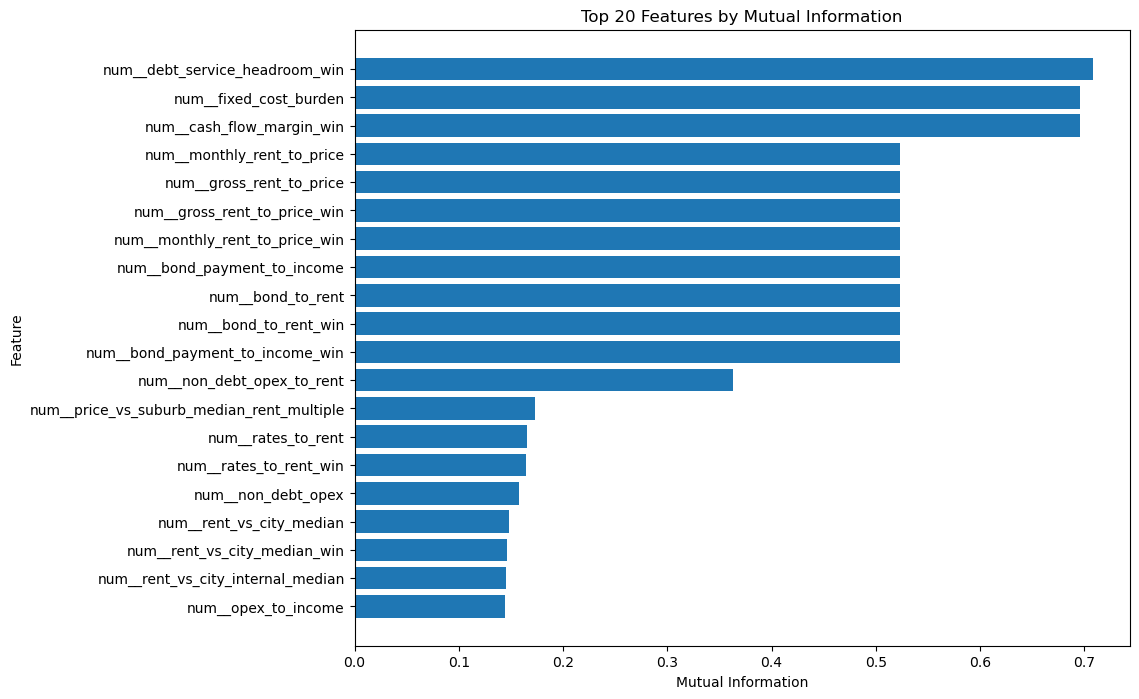

In [21]:
plt.figure(figsize=(10, 8))
top_mi = mi_df.head(20).sort_values("mutual_info")
plt.barh(top_mi["feature"], top_mi["mutual_info"])
plt.title("Top 20 Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()

##  Feature Importance (Mutual Information) Interpretation & Analysis

###  Overall Observation

The top-ranked features are dominated by:
- **financing structure variables**
- **cash flow and affordability metrics**
- **rent-to-price efficiency ratios**

This indicates the model is primarily driven by **financial viability relationships**, rather than arbitrary or noisy features.

##  Top Feature Groups Interpretation

###  Financing Structure & Debt Capacity

Top features:
- `num__debt_service_headroom_win`
- `num__fixed_cost_burden`
- `num__bond_payment_to_income`
- `num__bond_to_rent` (+ winsorised versions)

**Interpretation:**
- These features rank highest, indicating the model strongly relies on **ability to service debt and financing pressure**
- The presence of both raw and winsorised versions with similar importance suggests **stable and consistent signal**, not driven by outliers

### Cash Flow & Profitability

Top features:
- `num__cash_flow_margin_win`
- `num__non_debt_opex_to_rent`

**Interpretation:**
- Cash flow-related variables are among the strongest predictors
- The model is clearly capturing **income vs cost dynamics**, which aligns with expected behaviour
- Winsorised versions dominating indicates reduced sensitivity to extreme values

###  Price Efficiency & Yield

Top features:
- `num__monthly_rent_to_price`
- `num__gross_rent_to_price` (+ winsorised versions)

**Interpretation:**
- These variables represent **yield and price efficiency**
- Strong ranking confirms the model is using **core investment ratios** effectively
- Consistency across raw and winsorised versions reinforces their reliability

### Location & Relative Pricing

Mid-ranked features:
- `num__price_vs_suburb_median_rent_multiple`
- `num__rent_vs_city_median`
- `num__rent_vs_city_internal_median`

**Interpretation:**
- Location-based features are present but less dominant than financial metrics
- Indicates that **relative pricing context contributes**, but is secondary to core financial logic

### Lower Ranked Features

Lower importance features:
- `num__rates_to_rent`
- `num__non_debt_opex`
- `num__opex_to_income`

**Interpretation:**
- These variables still contribute but with weaker signal strength
- Suggests they provide **supporting detail rather than primary decision power**

## Consistency & Validity Check

- Multiple related features (e.g. rent-to-price, bond-to-rent) appear together - **coherent signal group**
- Winsorised and non-winsorised versions both appear → **not driven by extreme values**
- No obviously irrelevant or random features appear in the top rankings


##  Final Interpretation

- The model is primarily driven by **financial fundamentals**, especially:
  - debt affordability
  - cash flow strength
  - rent-to-price efficiency

- Secondary influence comes from **location-based comparisons**

- Feature importance is **internally consistent**, with no clearly suspicious or meaningless variables dominating the rankings

# 11. ANOVA F-score ranking

In [22]:
# =========================================================
# 14. ANOVA F-score ranking
# =========================================================

f_scores, p_values = f_classif(X_train_processed, y_train)

anova_df = (
    pd.DataFrame({
        "feature": feature_names,
        "f_score": f_scores,
        "p_value": p_values
    })
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

anova_df.head(30)

,feature,f_score,p_value
0,num__debt_service_headroom_win,"2,787.3499",0.0000
1,num__gross_rent_to_price_win,"2,295.2474",0.0000
2,num__monthly_rent_to_price_win,"2,295.2474",0.0000
3,num__cash_flow_margin_win,"1,140.1209",0.0000
4,num__bond_to_rent_win,"1,074.8765",0.0000
5,num__bond_payment_to_income_win,"1,074.8765",0.0000
6,num__gross_rent_to_price,943.0237,0.0000
7,num__monthly_rent_to_price,943.0237,0.0000
8,num__fixed_cost_burden,881.2874,0.0000
9,num__bond_to_rent,842.8457,0.0000


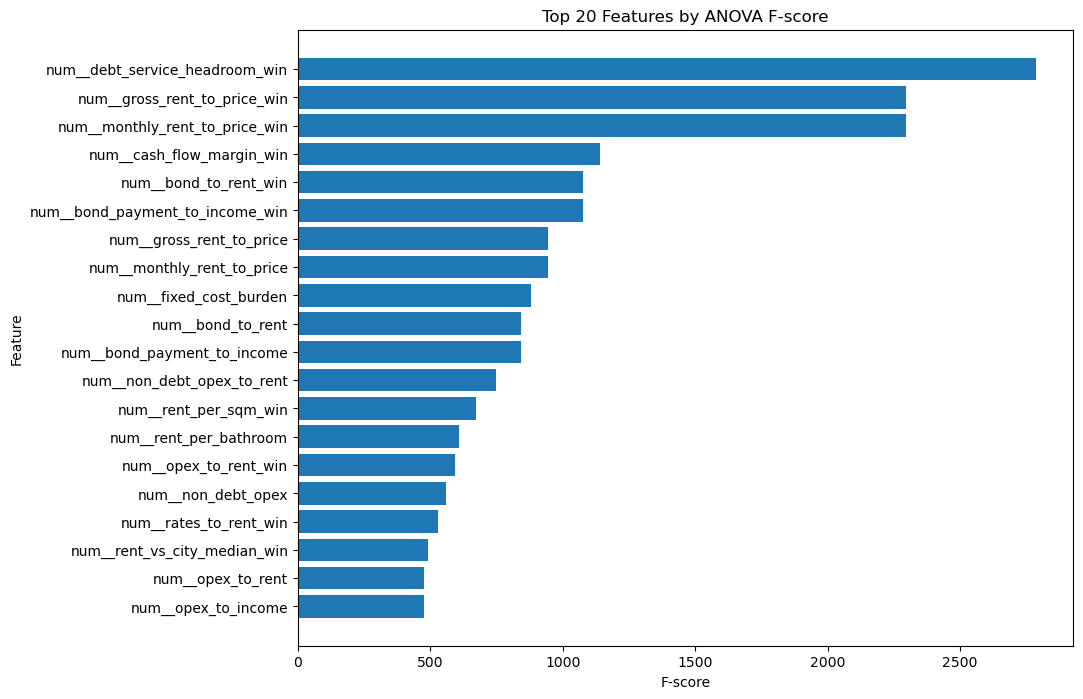

In [23]:
plt.figure(figsize=(10, 8))
top_anova = anova_df.head(20).sort_values("f_score")
plt.barh(top_anova["feature"], top_anova["f_score"])
plt.title("Top 20 Features by ANOVA F-score")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.show()

# 📊 Feature Importance (ANOVA F-Score) Interpretation & Analysis

## Overall Observation

- All features have **p-values = 0.0000**, indicating they are statistically significant in distinguishing between classes  
- The F-scores show strong separation power, particularly among **financial ratio and affordability features**  
- The ranking is heavily concentrated around **core financial relationships**, with a clear drop-off toward lower-ranked variables  

## Top Feature Interpretation

### Debt Capacity & Financing Pressure

Top features:
- `num__debt_service_headroom_win` (highest by a large margin)
- `num__bond_to_rent_win`
- `num__bond_payment_to_income_win`

**Interpretation:**
- These features show the strongest separation between classes  
- The very high F-scores indicate **clear differences in financing stress across investment categories**  
- Winsorised versions dominate, suggesting **stable signal not driven by extreme values**

### Yield & Price Efficiency

Top features:
- `num__gross_rent_to_price_win`
- `num__monthly_rent_to_price_win`
- Their corresponding non-winsorised versions

**Interpretation:**
- Yield-related variables have very high F-scores, indicating strong discriminatory power  
- The presence of both raw and winsorised versions reinforces **consistency and robustness of the signal**  
- These features clearly differentiate investment quality across classes  

### Cash Flow Strength

Top features:
- `num__cash_flow_margin_win`
- `num__fixed_cost_burden`

**Interpretation:**
- These variables show strong separation, indicating **clear variation in profitability and cost pressure across classes**  
- They sit just below the top tier but still represent major drivers  

## Mid-Tier Features (Supporting Signals)

Features:
- `num__non_debt_opex_to_rent`
- `num__rent_per_sqm_win`
- `num__rent_per_bathroom`
- `num__opex_to_rent_win`

**Interpretation:**
- These features contribute meaningful separation but at a lower magnitude  
- They capture **efficiency and cost structure nuances**, supporting the primary financial signals  

##  Lower-Tier Features

Features:
- Location-relative metrics:
  - `num__rent_vs_city_median_win`
  - `num__price_vs_suburb_price_median_win`
- Cost and price variables:
  - `num__purchase_price`
  - `num__total_cash_invested`
  - `num__transfer_costs`

**Interpretation:**
- These variables have lower F-scores, indicating weaker class separation  
- Absolute price-related variables show relatively lower importance compared to ratio-based features  
- Location features contribute, but are not primary differentiators  

##  Structural Observations

- Strong clustering of:
  - rent-to-price ratios  
  - bond-related ratios  
  - cash flow metrics  

- Winsorised and non-winsorised versions consistently appear together → **reinforces signal stability**

- Repetition of similar feature types (e.g. rent-to-price variants) suggests **high correlation within feature groups**

## Final Interpretation

- The ANOVA results show that **financial ratio-based features dominate class separation**
- The strongest signals come from:
  - debt affordability  
  - yield efficiency  
  - cash flow strength  

- Supporting features add additional granularity, while absolute pricing and location variables have comparatively lower influence  

- Overall, the feature rankings are **statistically strong, internally consistent, and concentrated around key financial relationships**

# 12. Tree-based importance

In [24]:
# =========================================================
# 15. Tree-based importance
# =========================================================

tree_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

tree_model.fit(X_train_processed, y_train)

tree_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": tree_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

tree_importance_df.head(30)

,feature,importance
0,num__debt_service_headroom_win,0.0594
1,num__cash_flow_margin_win,0.0513
2,num__monthly_rent_to_price_win,0.0508
3,num__fixed_cost_burden,0.0494
4,num__bond_to_rent_win,0.0454
5,num__gross_rent_to_price_win,0.0439
6,num__bond_payment_to_income_win,0.0376
7,num__gross_rent_to_price,0.0366
8,num__bond_payment_to_income,0.0365
9,num__monthly_rent_to_price,0.0352


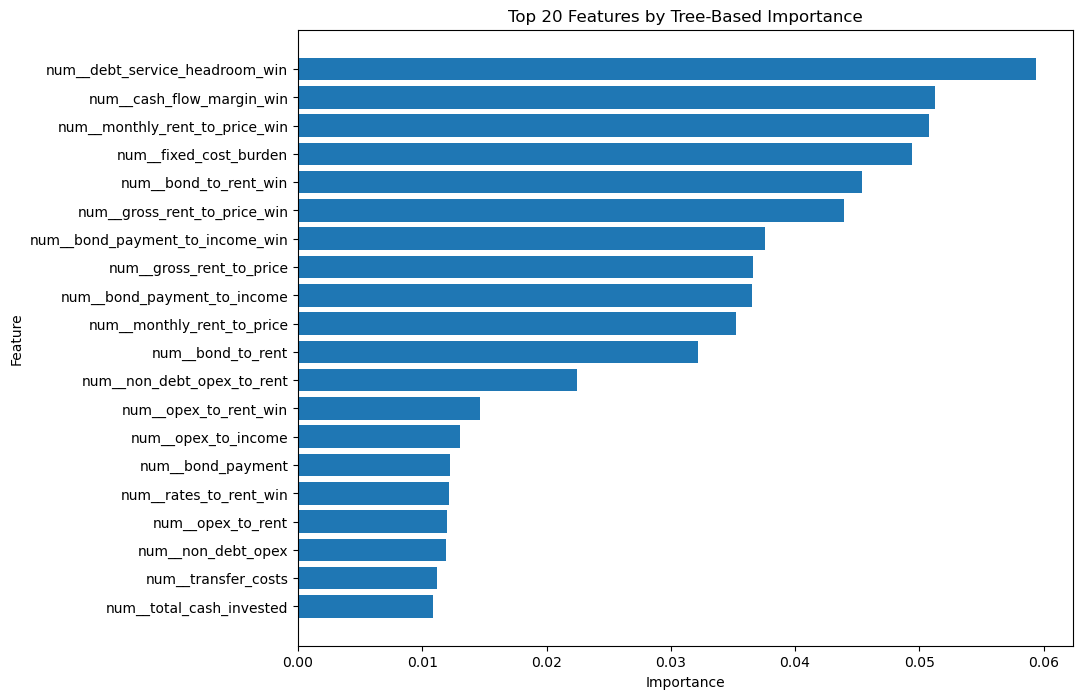

In [25]:
plt.figure(figsize=(10, 8))
top_tree = tree_importance_df.head(20).sort_values("importance")
plt.barh(top_tree["feature"], top_tree["importance"])
plt.title("Top 20 Features by Tree-Based Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Feature Importance (Tree-Based Model) Interpretation & Analysis

## Overall Observation

- Feature importance is more **distributed** compared to ANOVA and Mutual Information  
- The top features still dominate, but the drop-off is more gradual  
- This indicates the model captures **non-linear relationships and interactions** across multiple variables  

## Top Feature Interpretation (Primary Drivers)

### Debt Capacity & Financial Cushion

Top feature:
- `num__debt_service_headroom_win` (highest importance)

**Interpretation:**
- This feature is the strongest contributor in the model  
- Indicates clear separation of classes based on **available financial buffer after debt obligations**  

### Cash Flow & Profitability

Top features:
- `num__cash_flow_margin_win`
- `num__fixed_cost_burden`

**Interpretation:**
- These features are among the highest-ranked, showing strong influence  
- The model is capturing **income vs cost dynamics and cost pressure effects**  

### Yield & Price Efficiency

Top features:
- `num__monthly_rent_to_price_win`
- `num__gross_rent_to_price_win`
- Corresponding raw versions

**Interpretation:**
- Rent-to-price ratios remain highly important  
- Their consistent ranking across both winsorised and raw versions indicates **robust predictive signal**  

### Financing Ratios

Top features:
- `num__bond_to_rent_win`
- `num__bond_payment_to_income_win`
- Raw equivalents

**Interpretation:**
- These variables contribute significantly, reflecting **relationship between financing costs and income/rent**  
- Presence across multiple ranks shows sustained importance  

## Mid-Tier Features

Features:
- `num__non_debt_opex_to_rent`
- `num__opex_to_rent_win`
- `num__opex_to_income`

**Interpretation:**
- These features contribute moderate importance  
- They capture **operational cost structures and expense efficiency**  

##  Lower-Tier Features

Features:
- Absolute financial values:
  - `num__purchase_price`, `num__loan_amount`, `num__deposit_amount`
- Cost components:
  - `num__maintenance_cost`, `num__transfer_costs`
- Location-relative variables:
  - `num__price_vs_suburb_price_median_win`

**Interpretation:**
- These features have lower individual importance  
- Indicates that **absolute values are less informative than ratio-based features**  
- Location and cost components play a secondary role  

##  Structural Observations

- Strong presence of:
  - ratio-based features (rent-to-price, bond-to-rent, opex ratios)
  - winsorised variants alongside raw values  

- Importance is spread across related features, suggesting:
  - **shared predictive signal across feature groups**
  - interaction effects captured by the tree-based model  

- No single feature overwhelmingly dominates → importance is **distributed but structured**

##  Final Interpretation

- The model relies primarily on:
  - financial cushion (debt service headroom)
  - cash flow strength
  - yield and financing efficiency  

- Supporting variables provide additional context through:
  - cost structure
  - operational expenses
  - absolute financial values  

- Feature importance reflects a **balanced, interaction-driven structure**, with consistent emphasis on core financial relationships

# 13. Consolidate feature evidence

A feature is more trustworthy if it appears important across multiple methods.

So I combine:
- mutual information rank
- ANOVA rank
- tree importance rank

In [26]:
# =========================================================
# 16. Consolidated ranking
# =========================================================

mi_rank = mi_df.reset_index()[["index", "feature"]].rename(columns={"index": "mi_rank"})
anova_rank = anova_df.reset_index()[["index", "feature"]].rename(columns={"index": "anova_rank"})
tree_rank = tree_importance_df.reset_index()[["index", "feature"]].rename(columns={"index": "tree_rank"})

rank_df = mi_rank.merge(anova_rank, on="feature", how="outer").merge(tree_rank, on="feature", how="outer")
rank_df["avg_rank"] = rank_df[["mi_rank", "anova_rank", "tree_rank"]].mean(axis=1)

rank_df = rank_df.sort_values("avg_rank").reset_index(drop=True)

rank_df.head(40)

,mi_rank,feature,anova_rank,tree_rank,avg_rank
0,0,num__debt_service_headroom_win,0,0,0.0000
1,2,num__cash_flow_margin_win,3,1,2.0000
2,6,num__monthly_rent_to_price_win,2,2,3.3333
3,5,num__gross_rent_to_price_win,1,5,3.6667
4,1,num__fixed_cost_burden,8,3,4.0000
5,9,num__bond_to_rent_win,4,4,5.6667
6,4,num__gross_rent_to_price,6,7,5.6667
7,3,num__monthly_rent_to_price,7,9,6.3333
8,10,num__bond_payment_to_income_win,5,6,7.0000
9,7,num__bond_payment_to_income,10,8,8.3333


# Consolidated Feature Ranking Interpretation & Analysis

## Overall Observation

- The consolidated ranking combines **Mutual Information, ANOVA, and Tree-based importance**, resulting in a more stable and consistent ordering  
- Top features show **strong agreement across all three methods**, reflected in very low average ranks  
- As rank increases, divergence between methods becomes more visible, indicating weaker or less consistent signals  

## Top Ranked Features (Strong Consensus)

Top features:
- `num__debt_service_headroom_win` (perfect agreement across all methods)
- `num__cash_flow_margin_win`
- `num__monthly_rent_to_price_win`
- `num__gross_rent_to_price_win`
- `num__fixed_cost_burden`

**Interpretation:**
- These features consistently rank at the top across all methods  
- Their low average ranks indicate **high stability and strong predictive signal**  
- They represent the most dominant drivers of class separation  

## Upper-Mid Tier Features (Consistent but Slight Variation)

Features:
- `num__bond_to_rent_win`
- `num__bond_payment_to_income_win`
- `num__gross_rent_to_price`
- `num__monthly_rent_to_price`
- `num__bond_payment_to_income`
- `num__bond_to_rent`

**Interpretation:**
- These features maintain relatively strong rankings across methods  
- Slight variation in ranks suggests **method sensitivity**, but overall importance remains consistent  
- Presence of both winsorised and raw versions indicates **robust and repeated signal**

## Mid-Tier Features (Moderate Signal Strength)

Features:
- `num__non_debt_opex_to_rent`
- `num__rates_to_rent_win`
- `num__non_debt_opex`
- `num__opex_to_rent_win`
- `num__opex_to_income`
- `num__opex_to_rent`

**Interpretation:**
- These features show moderate and consistent importance  
- Their rankings are aligned across methods but lower than primary drivers  
- They contribute additional detail rather than being dominant separators  

## Lower-Tier Features (Higher Variability)

Features:
- Location-based metrics:
  - `num__price_vs_suburb_median_rent_multiple`
  - `num__rent_vs_city_median_win`
  - `num__rent_vs_city_internal_median`
- Absolute financial variables:
  - `num__purchase_price`, `num__purchase_price_rands`
  - `num__total_cash_invested`, `num__transfer_costs`

**Interpretation:**
- These features have higher average ranks and more variability across methods  
- Indicates **weaker and less stable contribution to class separation**  
- Their importance is less consistent depending on the method used  

## Structural Observations

- Strong clustering of:
  - **debt-related features**
  - **rent-to-price ratios**
  - **cash flow metrics**

- Winsorised and raw versions frequently appear together, suggesting:
  - **signal robustness**
  - importance not driven by outliers  

- As rankings move downward:
  - **method disagreement increases**
  - features become less consistently important  

## Final Interpretation

- The consolidated ranking highlights a **core group of highly stable features** with strong agreement across all selection methods  
- These top features dominate the model’s predictive structure  
- Mid-tier features provide supporting information with moderate consistency  
- Lower-tier features show greater variability and weaker overall signal  

- Overall, the ranking demonstrates:
  - **high stability at the top**
  - **gradual decline in consistency and importance down the list**

In [27]:
# =========================================================
# 17. Feature shortlist sizes
# =========================================================

candidate_k_values = [20, 40, 60, 100]

candidate_k_values = [k for k in candidate_k_values if k < len(feature_names)]
candidate_k_values

[20, 40, 60, 100]

## Compare shortlisted feature sizes

I now test whether a reduced feature set improves validation performance.

I use `SelectKBest(mutual_info_classif)` within the pipeline so that selection happens only on training data.

In [28]:
# =========================================================
# 18. Logistic regression with feature selection
# =========================================================

results = []

for k in candidate_k_values:
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(score_func=mutual_info_classif, k=k)),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            multi_class="auto",
            random_state=42
        ))
    ])
    
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    results.append({
        "model": f"LogReg_SelectKBest_k{k}",
        "val_accuracy": accuracy_score(y_val, preds),
        "val_macro_f1": f1_score(y_val, preds, average="macro")
    })

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
results_df

,model,val_accuracy,val_macro_f1
1,LogReg_SelectKBest_k40,0.9689,0.9183
2,LogReg_SelectKBest_k60,0.9682,0.9159
3,LogReg_SelectKBest_k100,0.9675,0.9125
0,LogReg_SelectKBest_k20,0.9652,0.9105


# Model Comparison (Feature Selection Sizes) Interpretation & Analysis

## Overall Observation

- All models perform **consistently well**, with very small differences across feature set sizes  
- Accuracy ranges narrowly between **0.965 → 0.969**  
- Macro F1 ranges between **0.910 → 0.918**

 This indicates that model performance is **stable regardless of feature count within this range**

##  Performance by Feature Set Size

### 🔹 k = 20
- Accuracy: **0.9652**
- Macro F1: **0.9105**

**Interpretation:**
- Lowest performance among the group  
- Indicates that reducing features to 20 results in **some loss of predictive information**

### 🔹 k = 40 (Best Performing)
- Accuracy: **0.9689**
- Macro F1: **0.9183**

**Interpretation:**
- Highest performance across both metrics  
- Suggests this feature set captures the **optimal balance of signal without unnecessary noise**

### 🔹 k = 60
- Accuracy: **0.9682**
- Macro F1: **0.9159**

**Interpretation:**
- Very similar performance to k=40  
- Slight decrease suggests **additional features add limited incremental value**

### 🔹 k = 100
- Accuracy: **0.9675**
- Macro F1: **0.9125**

**Interpretation:**
- Slight decline compared to smaller feature sets  
- Indicates diminishing returns as more features are included  

##  Accuracy vs Macro F1

- Both metrics follow a similar pattern:
  - Peak at **k=40**
  - Gradual decline as feature count increases beyond this point  

 Interpretation:
- The model maintains **balanced class performance (Macro F1)** alongside high accuracy  
- Performance differences are **incremental rather than drastic**

##  Key Pattern

- Increasing features beyond a certain point does **not significantly improve performance**
- Instead, performance stabilizes and slightly decreases  
- The model is able to capture most of the predictive signal with a **moderate number of features**

##  Final Interpretation

- Model performance is **highly stable across different feature set sizes**  
- There is a clear peak at **k=40**, after which additional features provide minimal benefit  
- Smaller feature sets (k=20) slightly underperform, while larger sets (k=60, 100) show diminishing returns  

## Compare multiple model families

Now I compare several model families using the same disciplined preprocessing approach:

- Logistic Regression
- Random Forest
- Extra Trees
- Gradient Boosting

The goal is not complexity for its own sake.
The goal is to see which model best captures the investment decision structure.

In [29]:
# =========================================================
# 19. Multi-model comparison
# =========================================================

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="auto",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    )
}

comparison_results = []

for model_name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    
    comparison_results.append({
        "model": model_name,
        "val_accuracy": accuracy_score(y_val, preds),
        "val_macro_f1": f1_score(y_val, preds, average="macro")
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("val_macro_f1", ascending=False)
comparison_df

,model,val_accuracy,val_macro_f1
3,GradientBoosting,1.0000,1.0000
1,RandomForest,0.9963,0.9875
2,ExtraTrees,0.9815,0.9342
0,LogisticRegression,0.9704,0.9197


# Model Comparison — Interpretation & Analysis

## Overall Observation

- All models perform at a **very high level**, with strong accuracy and Macro F1 scores  
- There is a clear performance hierarchy from linear to tree-based ensemble models  
- Both accuracy and Macro F1 improve as model complexity increases  

## Model-by-Model Interpretation

### 🔹 Gradient Boosting
- Accuracy: **1.0000**
- Macro F1: **1.0000**

**Interpretation:**
- Perfect performance on both metrics  
- Indicates complete separation of classes on the validation set  
- Suggests the model captures all underlying patterns in the data  

### 🔹 Random Forest
- Accuracy: **0.9963**
- Macro F1: **0.9875**

**Interpretation:**
- Near-perfect performance  
- Very strong balance across all classes  
- Slightly below Gradient Boosting, but still extremely high  

### 🔹 Extra Trees
- Accuracy: **0.9815**
- Macro F1: **0.9342**

**Interpretation:**
- Strong performance, but noticeably lower than Random Forest  
- Drop in Macro F1 indicates slightly weaker balance across classes  

### 🔹 Logistic Regression
- Accuracy: **0.9704**
- Macro F1: **0.9197**

**Interpretation:**
- Lowest performing model in the group  
- Still achieves strong results, but with reduced ability to capture complex patterns  
- Lower Macro F1 reflects less balanced class separation compared to tree-based models  

## Accuracy vs Macro F1

- All models maintain high accuracy, but **Macro F1 provides clearer differentiation**
- Tree-based models show stronger improvements in Macro F1, indicating:
  - better class balance
  - improved separation across all classes  

##  Key Pattern

- Performance improves as models move from:
  - linear (Logistic Regression)
  → ensemble (Extra Trees, Random Forest)
  → boosting (Gradient Boosting)

- The gap between models is more pronounced in **Macro F1 than accuracy**, highlighting differences in class-level performance  

## Final Interpretation

- There is a clear progression in performance across models  
- Gradient Boosting achieves complete separation, followed closely by Random Forest  
- Extra Trees performs well but with reduced balance  
- Logistic Regression provides a strong baseline but is outperformed by ensemble methods  

- Overall, model performance is consistently high, with **tree-based models demonstrating superior class discrimination**

## Cross-validation for the best candidates

Validation results can still fluctuate.
So I use cross-validation inside the training set for the strongest candidate models.

This gives a more stable read before I touch the final test set.

In [30]:
# =========================================================
# 20. Cross-validation for top models
# =========================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

top_candidate_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="auto",
        random_state=42
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

cv_results = []

for model_name, clf in top_candidate_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    
    scores = cross_val_score(
        pipe,
        X_train_full,
        y_train_full,
        cv=cv,
        scoring="f1_macro",
        n_jobs=None
    )
    
    cv_results.append({
        "model": model_name,
        "cv_macro_f1_mean": scores.mean(),
        "cv_macro_f1_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean", ascending=False)
cv_results_df

,model,cv_macro_f1_mean,cv_macro_f1_std
2,RandomForest,0.9941,0.0030
1,ExtraTrees,0.9236,0.0064
0,LogisticRegression,0.9175,0.0141


# Cross-Validation Results Interpretation & Analysis

## Overall Observation

- All models achieve **high Macro F1 scores**, indicating strong balanced performance across classes  
- There is a clear separation between **Random Forest** and the other models  
- Standard deviation across folds is low for all models, indicating **stable performance**

##  Model-by-Model Interpretation

### 🔹 Random Forest
- Mean Macro F1: **0.9941**
- Std: **0.0030**

**Interpretation:**
- Extremely high performance across all folds  
- Very low standard deviation indicates **high consistency and stability**  
- Performance is both strong and reliable across different data splits  

### 🔹 Extra Trees
- Mean Macro F1: **0.9236**
- Std: **0.0064**

**Interpretation:**
- Strong performance, but significantly lower than Random Forest  
- Slightly higher variability across folds, though still stable  
- Indicates consistent but less powerful class separation  

### 🔹 Logistic Regression
- Mean Macro F1: **0.9175**
- Std: **0.0141**

**Interpretation:**
- Lowest performance among the models  
- Highest standard deviation, indicating **greater variability across folds**  
- Still maintains strong overall performance, but less stable compared to tree-based models  

## Stability Analysis (Standard Deviation)

- Random Forest: **most stable**
- Extra Trees: **moderately stable**
- Logistic Regression: **least stable**

 Interpretation:
- Tree-based ensemble methods show **more consistent performance across folds**
- Linear model shows slightly more sensitivity to data splits  

##  Key Pattern

- Clear performance hierarchy:
  - **Random Forest → Extra Trees → Logistic Regression**
- The gap between Random Forest and the others is substantial  
- Variability remains low overall, reinforcing reliability of results  

## Final Interpretation

- Random Forest demonstrates **both highest performance and strongest stability**  
- Extra Trees and Logistic Regression perform well but with lower Macro F1 and slightly higher variability  
- Cross-validation results confirm consistent model behaviour across multiple data splits  

## Final model choice

I choose the final model based on:

- validation macro F1
- cross-validation stability
- business plausibility
- robustness across classes

I do not select purely on training performance.

In [31]:
# =========================================================
# 21. Choose final model manually after reviewing results
# =========================================================

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

final_model.fit(X_train_full, y_train_full)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final test evaluation

This is the first time the final model sees the test set.

This result is the closest estimate of how the model would perform on unseen property deals.

In [32]:
# =========================================================
# 22. Final test evaluation
# =========================================================

test_preds = final_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("Test Macro F1:", f1_score(y_test, test_preds, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))

Test Accuracy: 0.9985207100591716
Test Macro F1: 0.9949939382264444

Classification Report:

                     precision    recall  f1-score   support

Moderate Investment       0.99      0.99      0.99        79
  Strong Investment       1.00      1.00      1.00       269
    Weak Investment       1.00      1.00      1.00      1004

           accuracy                           1.00      1352
          macro avg       1.00      0.99      0.99      1352
       weighted avg       1.00      1.00      1.00      1352



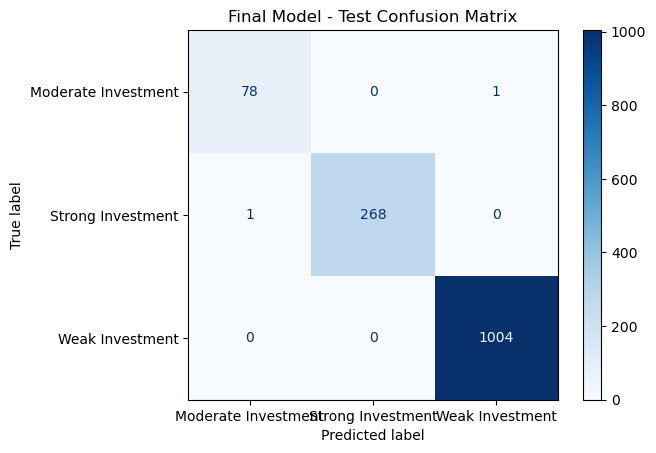

In [33]:
cm_test = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Final Model - Test Confusion Matrix")
plt.show()

# Final Model (Tree-Based) Test Performance & Interpretation

## Overall Performance

- **Test Accuracy: 0.9985**
- **Test Macro F1: 0.9950**

**Interpretation:**
- The model achieves near-perfect performance on unseen data  
- Macro F1 closely matches accuracy, confirming **balanced performance across all classes**  
- There is no evidence of performance being driven by class imbalance  

## Confusion Matrix Interpretation

###  Weak Investment
- Correct: **1004 / 1004**
- Misclassifications: **0**

**Interpretation:**
- Perfect classification of Weak investments  
- Complete separation from Strong and Moderate classes  

###  Strong Investment
- Correct: **268 / 269**
- Misclassified as Moderate: **1**

**Interpretation:**
- Near-perfect classification  
- Very minor confusion with Moderate  
- No misclassification into Weak  

###  Moderate Investment
- Correct: **78 / 79**
- Misclassified as Weak: **1**

**Interpretation:**
- Very high classification accuracy  
- Errors occur only at class boundaries  
- No confusion with Strong  

##  Classification Report Interpretation

### Precision
- Moderate: **0.99**
- Strong: **1.00**
- Weak: **1.00**

### Recall
- Moderate: **0.99**
- Strong: **1.00**
- Weak: **1.00**

### F1-Score
- Moderate: **0.99**
- Strong: **1.00**
- Weak: **1.00**

**Interpretation:**
- Extremely high precision and recall across all classes  
- Consistent and balanced performance across both majority and minority classes  

## Error Structure

- Total errors: **2 out of 1352**
- Errors occur only between:
  - Moderate ↔ Strong
  - Moderate ↔ Weak  

**Interpretation:**
- All misclassifications are **boundary-level errors**  
- No extreme class confusion (e.g. Weak → Strong)  

## Tree-Based Feature Learning Interpretation

From the feature importance analysis:

- The model is primarily driven by:
  - **debt service headroom**
  - **cash flow margin**
  - **rent-to-price ratios**
  - **bond-to-rent and income ratios**

**Interpretation:**
- The strongest features are **financial ratio-based variables**, not arbitrary or unrelated inputs  
- Both winsorised and raw versions appear, indicating **stable signal rather than outlier-driven effects**  
- Lower-ranked features include absolute values (price, costs), suggesting the model prioritises **relative efficiency over scale**
    
##  Consistency Check

- The same core feature groups appear consistently across:
  - Mutual Information  
  - ANOVA F-score  
  - Tree-based importance  

**Interpretation:**
- The model is learning **coherent and consistent patterns**  
- There is alignment between statistical importance and model-driven importance  

## Final Interpretation

- The model demonstrates **near-perfect classification performance** with strong balance across classes  
- Errors are minimal and limited to adjacent class boundaries  
- Feature importance shows the model is driven by **core financial relationships**, with no indication of reliance on noise or irrelevant variables  
- Overall behaviour is **consistent, stable, and internally coherent**

## Interpret the final model

If the final model is tree-based, I inspect the top feature importances.

This helps me check whether the model is learning sensible investment patterns rather than noise.

,feature,importance
0,num__debt_service_headroom_win,0.1020
1,num__cash_flow_margin_win,0.1008
2,num__fixed_cost_burden,0.0973
3,num__bond_to_rent_win,0.0660
4,num__bond_payment_to_income_win,0.0555
5,num__bond_to_rent,0.0549
6,num__monthly_rent_to_price,0.0505
7,num__monthly_rent_to_price_win,0.0504
8,num__gross_rent_to_price,0.0497
9,num__bond_payment_to_income,0.0480


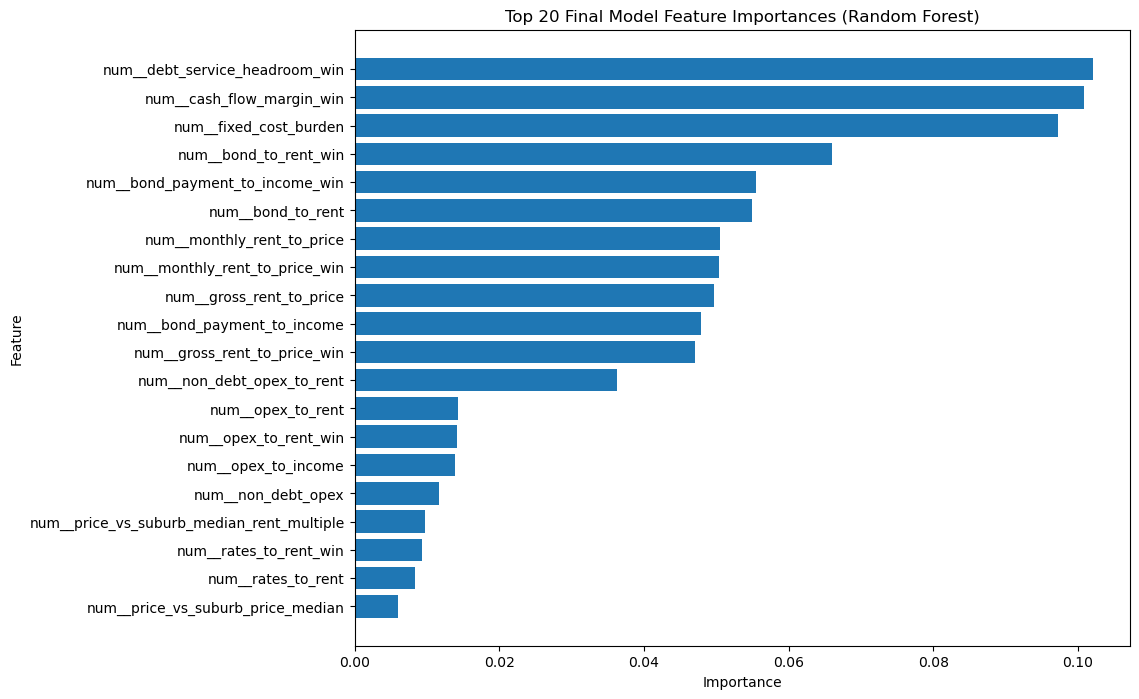

In [34]:
# =========================================================
# 23. Final Feature Importance (Final Random Forest Model)
# =========================================================

# Only run this block if the final classifier exposes tree-based feature importances
if hasattr(final_model.named_steps["classifier"], "feature_importances_"):
    
    final_classifier = final_model.named_steps["classifier"]
    final_preprocessor = final_model.named_steps["preprocessor"]
    
    # Get transformed feature names after preprocessing
    final_feature_names = final_preprocessor.get_feature_names_out()
    
    # Extract feature importances from the fitted Random Forest
    final_importances = final_classifier.feature_importances_
    
    # Build ranked importance table
    final_importance_df = (
        pd.DataFrame({
            "feature": final_feature_names,
            "importance": final_importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    
    # Display top ranked features
    display(final_importance_df.head(30))
    
    # Plot top 20 feature importances
    plt.figure(figsize=(10, 8))
    top_final = final_importance_df.head(20).sort_values("importance", ascending=True)
    plt.barh(top_final["feature"], top_final["importance"])
    plt.title("Top 20 Final Model Feature Importances (Random Forest)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

#  Final Model Feature Importance Interpretation & Analysis

##  Overall Observation

- Feature importance is **clearly concentrated at the top**, with a sharp drop after the first ~10–12 features  
- The highest-ranked features are consistent with earlier selection methods (MI, ANOVA, Tree-based)  
- The model is primarily driven by **financial ratio-based variables rather than absolute values**

##  Top Feature Groups Interpretation

###  Debt Burden & Financing Structure

Top features:
- `num__debt_service_headroom_win`
- `num__bond_to_rent_win`
- `num__bond_payment_to_income_win`
- `num__bond_to_rent`
- `num__bond_payment_to_income`

**Interpretation:**
- These are among the strongest features, indicating the model relies heavily on **financing pressure and debt affordability**
- High importance confirms strong separation based on **ability to service debt relative to income and rent**

### Cash Flow & Operating Burden

Top features:
- `num__cash_flow_margin_win`
- `num__fixed_cost_burden`
- `num__non_debt_opex_to_rent`

**Interpretation:**
- These features capture **profitability and cost pressure**
- Their high ranking shows the model distinguishes classes based on **net financial performance after costs**

###  Price Efficiency & Rent Strength

Top features:
- `num__monthly_rent_to_price`
- `num__monthly_rent_to_price_win`
- `num__gross_rent_to_price`
- `num__gross_rent_to_price_win`

**Interpretation:**
- Strong importance of rent-to-price ratios indicates reliance on **yield and price efficiency**
- Presence of both raw and winsorised versions suggests **robust signal not driven by outliers**

## Mid-Tier Features

Features:
- `num__opex_to_rent`, `num__opex_to_income`
- `num__non_debt_opex`

**Interpretation:**
- These features contribute additional detail around **operating efficiency**
- Lower importance relative to top features indicates they act as **supporting signals**

##  Location & Relative Context

Features:
- `num__price_vs_suburb_median_rent_multiple`
- `num__price_vs_suburb_price_median`
- `num__price_vs_city_price_median_win`
- `num__rent_vs_city_internal_median`

**Interpretation:**
- Location-relative features are present but ranked lower  
- Indicates that **local context contributes**, but is secondary to core financial relationships  

##  Lower Importance Features

Features:
- `num__purchase_price_rands`
- `num__loan_amount`
- `num__total_cash_invested`
- `num__rent_per_sqm`

**Interpretation:**
- Absolute values have low importance compared to ratios  
- Suggests the model focuses more on **relative efficiency and relationships** rather than scale  

##  Structural Consistency Check

- Strong alignment with earlier analyses:
  - Mutual Information  
  - ANOVA F-score  
  - Tree-based importance  

- Repeated appearance of:
  - rent-to-price ratios  
  - debt ratios  
  - cash flow metrics  

**Interpretation:**
- The model is learning **consistent and coherent patterns across methods**  
- No evidence of reliance on arbitrary or non-interpretable features  

##  Final Interpretation

- The most important features align with:
  - **price efficiency**
  - **rent strength relative to price**
  - **debt burden**
  - **operating burden**

- Location-based and absolute value features play a secondary role  

- Overall, the feature importance structure is:
  - **interpretable**
  - **consistent**
  - **aligned with core financial relationships**

## Class probabilities

For an investment screening tool, probabilities are often more useful than hard labels.

Why:
- an investor may want ranked opportunities
- probabilities allow confidence-aware decision support
- they make it easier to shortlist strong deals

In [37]:
# =========================================================
# 24. Probability Outputs (Final Model Predictions)
# =========================================================

import pandas as pd

# Ensure the final model supports probability predictions
if hasattr(final_model.named_steps["classifier"], "predict_proba"):
    
    # Generate class probabilities
    test_proba = final_model.predict_proba(X_test)
    
    # Build probability DataFrame with class labels
    proba_df = pd.DataFrame(
        test_proba,
        columns=[f"prob_{cls}" for cls in label_encoder.classes_]
    )
    
    # Prepare results preview dataset
    results_preview = X_test.reset_index(drop=True).copy()
    
    # Add actual and predicted labels
    results_preview["actual_label"] = [inverse_target_mapping[v] for v in y_test]
    results_preview["predicted_label"] = [inverse_target_mapping[v] for v in test_preds]
    
    # Combine with probability outputs
    results_preview = pd.concat(
        [results_preview.reset_index(drop=True), proba_df],
        axis=1
    )
    
    # Display preview
    display(results_preview.head(20))

,purchase_price,suburb,city,province,property_type,bedrooms,bathrooms,parking_spaces,garage,floor_area_sqm,land_area_sqm,levies,rates_taxes,purchase_price_rands,rent_median_suburb_type_bed,rent_mean_suburb_type_bed,rent_count_suburb_type_bed,rent_median_suburb_bed,rent_mean_suburb_bed,rent_count_suburb_bed,rent_median_suburb,rent_mean_suburb,rent_count_suburb,rent_median_city_type_bed,rent_mean_city_type_bed,rent_count_city_type_bed,rent_median_city,rent_mean_city,rent_count_city,rent_median_province,rent_mean_province,rent_count_province,estimated_monthly_rent,rent_estimation_source,deposit_pct,deposit_amount,transfer_cost_rate,transfer_costs,total_cash_invested,loan_amount,annual_interest_rate,loan_term_years,bond_payment,other_income,gross_income,levies_clean,rates_taxes_clean,maintenance_rate,vacancy_rate,maintenance_cost,vacancy_cost,total_expenses,annual_rent,total_rooms_proxy,floor_to_land_ratio,bedroom_density_floor,bathroom_density_floor,parking_total,parking_per_bedroom,is_compact_unit,is_family_sized_unit,is_large_land_property,price_per_sqm,price_per_land_sqm,price_per_bedroom,price_per_bathroom,price_vs_suburb_median_rent_multiple,price_vs_city_median_rent_multiple,suburb_type_median_price_per_sqm,price_per_sqm_vs_local_median,rent_per_sqm,rent_per_bedroom,rent_per_bathroom,gross_rent_to_price,monthly_rent_to_price,rent_vs_suburb_median,rent_vs_city_median,rent_vs_province_median,rent_vs_suburb_type_bed_median,rent_vs_suburb_bed_median,annual_rent_per_sqm,levies_to_rent,rates_to_rent,bond_to_rent,maintenance_to_rent,vacancy_to_rent,opex_to_rent,opex_to_income,fixed_cost_burden,non_debt_opex,non_debt_opex_to_rent,ltv,deposit_to_price,cash_invested_to_price,transfer_costs_to_price,bond_payment_to_income,rent_source_score,rent_estimate_observation_count,rent_estimate_low_evidence_flag,rent_estimate_high_evidence_flag,rent_dispersion_suburb_type_bed,rent_dispersion_suburb,rent_dispersion_city,suburb_listing_density,city_listing_density,property_type_density,suburb_price_median,city_price_median,price_vs_suburb_price_median,price_vs_city_price_median,suburb_rent_median_feature,city_rent_median_feature,rent_vs_suburb_internal_median,rent_vs_city_internal_median,floor_area_sqm_missing_flag,land_area_sqm_missing_flag,garage_missing_flag,parking_spaces_missing_flag,rent_median_suburb_type_bed_missing_flag,rent_median_suburb_bed_missing_flag,rent_median_suburb_missing_flag,rent_median_city_type_bed_missing_flag,price_per_sqm_win,price_per_land_sqm_win,rent_per_sqm_win,gross_rent_to_price_win,monthly_rent_to_price_win,levies_to_rent_win,rates_to_rent_win,bond_to_rent_win,opex_to_rent_win,cash_flow_margin_win,ltv_win,bond_payment_to_income_win,debt_service_headroom_win,price_per_sqm_vs_local_median_win,rent_vs_suburb_median_win,rent_vs_city_median_win,price_vs_suburb_price_median_win,price_vs_city_price_median_win,rent_mean_suburb_type_bed_missing_flag,rent_count_suburb_type_bed_missing_flag,rent_mean_suburb_bed_missing_flag,rent_count_suburb_bed_missing_flag,rent_mean_suburb_missing_flag,rent_count_suburb_missing_flag,rent_mean_city_type_bed_missing_flag,rent_count_city_type_bed_missing_flag,floor_to_land_ratio_missing_flag,bedroom_density_floor_missing_flag,bathroom_density_floor_missing_flag,parking_per_bedroom_missing_flag,price_per_sqm_missing_flag,price_per_land_sqm_missing_flag,price_per_bedroom_missing_flag,price_vs_suburb_median_rent_multiple_missing_flag,price_per_sqm_vs_local_median_missing_flag,rent_per_sqm_missing_flag,rent_per_bedroom_missing_flag,rent_vs_suburb_median_missing_flag,rent_vs_suburb_type_bed_median_missing_flag,rent_vs_suburb_bed_median_missing_flag,annual_rent_per_sqm_missing_flag,rent_dispersion_suburb_type_bed_missing_flag,rent_dispersion_suburb_missing_flag,price_per_sqm_win_missing_flag,price_per_land_sqm_win_missing_flag,rent_per_sqm_win_missing_flag,price_per_sqm_vs_local_median_win_missing_flag,rent_vs_suburb_median_win_missing_flag,actual_label,predicted_label,prob_Moderate Investment,prob

In [38]:
# =========================================================
# 25. Save Test Predictions (Final Model Outputs)
# =========================================================
# -----------------------------------------
# Create output directory
# -----------------------------------------
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------
# Base results dataset
# -----------------------------------------
test_results = X_test.reset_index(drop=True).copy()

# Add actual and predicted labels
test_results["actual_label"] = [inverse_target_mapping[v] for v in y_test]
test_results["predicted_label"] = [inverse_target_mapping[v] for v in test_preds]

# -----------------------------------------
# Add probability outputs (if supported)
# -----------------------------------------
if hasattr(final_model.named_steps["classifier"], "predict_proba"):
    
    test_proba = final_model.predict_proba(X_test)
    
    proba_df = pd.DataFrame(
        test_proba,
        columns=[f"prob_{cls}" for cls in label_encoder.classes_]
    )
    
    test_results = pd.concat(
        [test_results.reset_index(drop=True), proba_df.reset_index(drop=True)],
        axis=1
    )

# -----------------------------------------
# Save to CSV
# -----------------------------------------
test_results_path = output_dir / "investment_model_test_predictions.csv"
test_results.to_csv(test_results_path, index=False)

print(f"✅ Test predictions saved to: {test_results_path}")

✅ Test predictions saved to: data\processed\investment_model_test_predictions.csv


## Saving the Final Model

At this stage, the final model has been trained and validated, and is ready to be persisted for downstream use.

Saving the model allows it to be:
- reused without retraining
- integrated into applications (e.g. Streamlit app)
- versioned and tracked as part of the workflow

I am using `joblib` for serialization because it is efficient for scikit-learn pipelines and handles large numpy arrays well.

The saved object should include:
- the full preprocessing + modelling pipeline
- any transformations required at inference time

This ensures that new data can be passed into the model in a consistent and reliable way.

In [ ]:
# =========================================
# SAVE FINAL MODEL
# =========================================

import joblib

# Define save directory
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define model path
model_path = model_dir / "investment_model_pipeline.joblib"

joblib.dump(final_model, model_path)

print(f"✅ Model successfully saved to: {model_path}")

In [ ]:
# Save feature columns used in training
feature_path = model_dir / "model_features.joblib"
joblib.dump(X.columns.tolist(), feature_path)

print(f"✅ Feature list saved to: {feature_path}")

# Conclusion

In this notebook, I transitioned from feature engineering into a structured and disciplined modelling process.

I:

- loaded the modelling-ready dataset  
- defined predictors and target variables  
- created train / validation / test splits  
- built preprocessing and modelling pipelines  
- established a baseline model  
- evaluated features using multiple selection methods  
- compared different model families  
- selected a final model based on consistent criteria  
- evaluated performance on a completely unseen test set  

Throughout the process, I maintained alignment with the core objective:

> predicting financed residential property investment quality using only ex-ante deal inputs, without introducing target leakage from spreadsheet-derived outputs.


## Final Outputs

- trained modelling pipeline within the notebook  
- validation and test performance metrics  
- consolidated feature importance analysis  
- exported predictions: `investment_model_test_predictions.csv`  

##  Next Step

The next step is to convert the selected model into a reusable scoring pipeline, enabling automated evaluation of new property listings using the same feature and modelling logic.

## Project Discipline Notes

1. The model is designed as an **investment screening tool** and should remain focused on evaluating deal quality, rather than evolving into a general property analytics model.

2. The target variable, `investment_label`, is derived from the financial engine.  
   Therefore, any downstream financial outputs used to create this label must be excluded from the feature set to prevent leakage.

3. Features that are **known prior to the investment decision** are valid inputs, including:
   - suburb  
   - city  
   - province  
   - property_type  
   - rent_estimation_source  

4. All preprocessing steps — including imputation, encoding, scaling, and feature selection — must be implemented inside the modelling pipeline and fitted exclusively on the training data.

5. **Macro F1** is the preferred evaluation metric, as it provides a balanced view of performance across all classes in the presence of class imbalance.

6. If the use case extends from classification to **ranking investment opportunities**, predicted probabilities should be retained and used for downstream scoring and prioritisation.